In [2]:
import numpy as np
import torch
import os
import sys
import yaml
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import torch
import pandas as pd

helpers_path = os.path.join('/home/aegis/Titan1/NRAD/data/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
CUDA = torch.cuda.is_available()
CUDA = False
device = torch.device("cuda" if CUDA else "cpu")
print("Device:", device)

dataset_path = "/home/aegis/Titan1/NRAD/data/Scaled_Regions"
dataset_path_weighted = "/Titan1/aegis/NRAD/data/Scaled_Regions_with_weights"
config_path = "/home/aegis/Titan1/NRAD/data/configs"
model_path = "/home/aegis/Titan1/NRAD/data/Models"
eval_dir = f"CWoLa_SR"

with open(f"{config_path}/bc_discrim.yml", 'r') as stream:
    params = yaml.safe_load(stream)

Device: cpu


In [4]:
print("Loadding Test events...")
mc_events_sr = pd.read_parquet(os.path.join(dataset_path, "MC_SR_test.parquet"))
mc_events_sr_weighted = pd.read_parquet(os.path.join(dataset_path_weighted, "MC_SR_test.parquet"))
data_events_sr = pd.read_parquet(os.path.join(dataset_path, "Data_SR_test.parquet"))

context_var = ['ht', 'met_recalc_pt']
features = [col for col in data_events_sr.columns if col not in context_var]

print("Context Variables:", context_var)
print("Feature Variables:", features)

Loadding Test events...
Context Variables: ['ht', 'met_recalc_pt']
Feature Variables: ['mjj', 'pt_balance', 'dphi_j1_j2', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'min_dphi_jet_met']


In [ ]:
def regularize_weights(w_arr, sigma = 3.0):
    w_copy = np.copy(w_arr)
    mean_w = np.mean(w_copy)
    std_w = np.std(w_copy)
    print("regularizing")
    w_copy[w_copy > (sigma*std_w + mean_w)] = 0
    return w_copy
def run_eval(set_1, set_2, code, save_dir, classifier_params, device, w_1 = None, w_2 = None, classifier_runs = 20):

    if w_1 is None or w_1.size == 0:
        w_1 = np.ones(set_1.shape[0])
    if w_2 is None or w_2.size == 0:
        w_2 = np.ones(set_2.shape[0])

    w_1 = regularize_weights(w_1)
    w_2 = regularize_weights(w_2)

    # define test size — roughly 20% or limited to 10,000 samples
    test_size_ratio = min(10000 / set_1.shape[0], 0.2)

    # split each dataset independently
    trainset_1, testset_1, wtrain_1, wtest_1 = train_test_split(
        set_1, w_1, test_size=test_size_ratio, random_state=42
    )
    trainset_2, testset_2, wtrain_2, wtest_2 = train_test_split(
        set_2, w_2, test_size=test_size_ratio, random_state=42
    )

    # ---------- Build train/test sets ----------
    # Combine the two datasets
    input_x_train = np.concatenate([trainset_1, trainset_2], axis=0)
    input_y_train = np.concatenate([
        np.zeros(trainset_1.shape[0]),
        np.ones(trainset_2.shape[0])
    ]).reshape(-1, 1)
    input_w_train = np.concatenate([wtrain_1, wtrain_2], axis=0).reshape(-1, 1)

    input_x_test = np.concatenate([testset_1, testset_2], axis=0)
    input_y_test = np.concatenate([
        np.zeros(testset_1.shape[0]),
        np.ones(testset_2.shape[0])
    ]).reshape(-1, 1)
    # input_w_test = np.concatenate([wtest_1, wtest_2], axis=0).reshape(-1, 1)

    
    # ---------- Logging ----------
    print(f"\nWorking on {code}...")
    print("      X_train, y_train, w_train:", input_x_train.shape, input_y_train.shape, input_w_train.shape)
    print("      X_test, y_test:", input_x_test.shape, input_y_test.shape)
    
    aucs_list = []

    for i in range(int(classifier_runs)):
        
        print(f"Classifier run {i+1} of {classifier_runs}.")
        local_id = f"{code}_run{i}"
                
        # train classifier
        NN = Classifier(n_inputs=8, layers=classifier_params["layers"], learning_rate=classifier_params["learning_rate"], device=device, scale_data=False)
        print("Using device:", NN.device)
        NN.train(input_x_train, input_y_train, weights=input_w_train,  save_model=True, model_name = f"model_{local_id}" , n_epochs=classifier_params["n_epochs"], seed = i, outdir=save_dir)

        scores = NN.evaluation(input_x_test)
        eval_weights = np.clip(np.concatenate([wtest_1, wtest_2]), 0, None)
        auc = roc_auc_score(input_y_test, scores, sample_weight=eval_weights)
        if auc < 0.5:
            auc = 1.0 - auc  # symmetry adjustment
        aucs_list.append(auc)
        print(f"   AUC: {auc}")
    
    # ---------- Save results ----------
    os.makedirs(f"{save_dir}/auc_scores", exist_ok=True)
    np.savez(f"{save_dir}/auc_scores/auc_{code}.npz", auc_scores=np.array(aucs_list))

    print("\nMedian AUC, 16th percentile, 84th percentile:")
    print(np.median(aucs_list), [np.percentile(aucs_list, 16), np.percentile(aucs_list, 84)])
    print("Done.\n")


In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os

def plot_publication_features_1row(set_1, set_2, w_1, feature_names=None, save_dir="eval_plots", unity = False):
    """
    Creates a single, wide publication-quality figure with 1 row of main histograms 
    and 1 row of ratio panels underneath for all features.
    """
    os.makedirs(save_dir, exist_ok=True)
    num_features = set_1.shape[1]
    
    # Global Matplotlib settings
    plt.rcParams.update({
        'font.size': 12,
        'axes.labelsize': 14,
        'axes.titlesize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.top': True,
        'ytick.right': True,
        'axes.linewidth': 1.2,
    })

    # Dynamically scale width: ~4.5 inches per feature, 6 inches total height
    fig = plt.figure(figsize=(4.5 * num_features, 6))
    
    # GridSpec: 2 rows (main, ratio), N columns. 
    # hspace controls vertical gap, wspace controls horizontal gap between features.
    gs = gridspec.GridSpec(2, num_features, height_ratios=[3, 1], hspace=0.08, wspace=0.35)
    
    for i in range(num_features):
        feat_name = feature_names[i] if feature_names is not None else f"Feature_{i}"
        
        # Determine binning
        min_val = min(np.min(set_1[:, i]), np.min(set_2[:, i]))
        max_val = max(np.max(set_1[:, i]), np.max(set_2[:, i]))
        bins = np.linspace(min_val, max_val, 51)  # 50 bins
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bin_width = bins[1] - bins[0]
        
        # Assign subplots in the grid
        ax_main = fig.add_subplot(gs[0, i])
        ax_ratio = fig.add_subplot(gs[1, i], sharex=ax_main)
        
        # --- TOP PANEL: MAIN HISTOGRAMS ---
        
        # Background (Set 1)
        hist_bkg, _ = np.histogram(set_1[:, i], bins=bins, weights=w_1)
        hist_bkg_err2, _ = np.histogram(set_1[:, i], bins=bins, weights=w_1**2)
        hist_bkg_err = np.sqrt(hist_bkg_err2)
        
        ax_main.hist(bins[:-1], bins=bins, weights=hist_bkg, 
                     color='#87CEEB', alpha=1.0, label='Extrapolated Bkg', 
                     histtype='stepfilled', edgecolor='blue', linewidth=1, density=unity)
        
        # Data (Set 2)
        hist_data, _ = np.histogram(set_2[:, i], bins=bins, density=unity)
        hist_data_err = np.sqrt(hist_data)
        
        ax_main.errorbar(bin_centers, hist_data, yerr=hist_data_err, 
                         fmt='ko', markersize=4, capsize=0, 
                         label='SR Data', zorder=4)
        
        ax_main.set_ylabel(f'Events / {bin_width:.2g}')
        ax_main.set_xlim(min_val, max_val)
        ax_main.semilogy()
        
        # Only put the legend on the first plot to keep the row clean
        if i == 0:
            ax_main.legend(loc='upper right', frameon=False, fontsize=10)
        
        plt.setp(ax_main.get_xticklabels(), visible=False)
        
        max_y = max(np.max(hist_data), np.max(hist_bkg))
        ax_main.set_ylim(0, max_y * 1.3)

        # --- BOTTOM PANEL: RATIO ---
        
        safe_bkg = np.where(hist_bkg == 0, 1e-10, hist_bkg)
        ratio = hist_data / safe_bkg
        ratio_err = hist_data_err / safe_bkg
        
        ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, 
                          fmt='ko', markersize=4, capsize=0)
        
        ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1.5)
        
        ax_ratio.set_ylabel('Data/Bkg', fontsize=12)
        ax_ratio.set_xlabel(feat_name)
        
        ax_ratio.set_ylim(0.5, 1.5)
        ax_ratio.set_yticks([0.5, 1.0, 1.5])
        ax_ratio.grid(axis='y', linestyle=':', alpha=0.6)
        
        ax_main.minorticks_on()
        ax_ratio.minorticks_on()
        
    # Save the single combined plot
    # save_path_pdf = os.path.join(save_dir, "All_Features_1Row.pdf")
    # save_path_png = os.path.join(save_dir, "All_Features_1Row.png")
    
    # Use bbox_inches='tight' to ensure no labels are cut off
    # fig.savefig(save_path_pdf, bbox_inches='tight')
    # fig.savefig(save_path_png, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig)
    # print(f"Combined 1-row plot saved to: {save_path_pdf}")

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


CWoLA Evaluation on Reweight Samples
CR has 76255 data events, 38813 MC events.
Shapes of feature arrays: (76255, 10) (38813, 10)
Loading model from: /home/aegis/Titan1/NRAD/data/Models/reweight.pt
10
Generating samples
Generating publication plots to diagnose AUC issue...


/tmp/ipykernel_202302/3026741794.py:79: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax_main.set_ylim(0, max_y * 1.3)


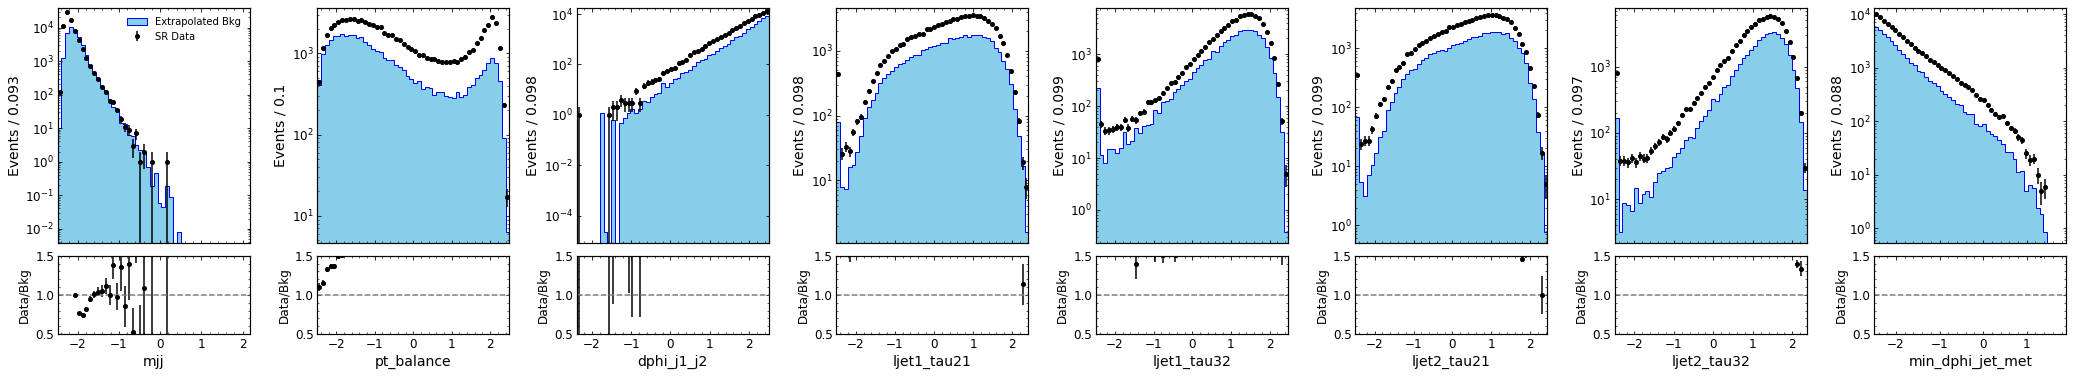


Working on reweight_sr...
      X_train, y_train, w_train: (92054, 8) (92054, 1) (92054, 1)
      X_test, y_test: (23014, 8) (23014, 1)
Classifier run 1 of 20.
Using device: cpu


 36%|===>      | 18/50 [09:30<16:54, 31.72s/it]


   AUC: 0.7156658314547955
Classifier run 2 of 20.
Using device: cpu


 46%|====>     | 23/50 [12:19<14:28, 32.16s/it]


   AUC: 0.7174927993184644
Classifier run 3 of 20.
Using device: cpu


...

 32%|===       | 16/50 [08:46<18:38, 32.91s/it]


   AUC: 0.721741969874286
Classifier run 19 of 20.
Using device: cpu


 40%|====      | 20/50 [10:30<15:46, 31.54s/it]


   AUC: 0.7221053576647907
Classifier run 20 of 20.
Using device: cpu


  6%|>         | 3/50 [01:29<24:43, 31.56s/it]

In [ ]:
print("CWoLA Evaluation on Reweight Samples")

print("CR has", len(data_events_sr), "data events,", len(mc_events_sr), "MC events.")
print("Shapes of feature arrays:", data_events_sr.shape, mc_events_sr.shape)
data_sr_test = data_events_sr.values
mc_sr_test = mc_events_sr.values

model = "reweight"
model_path_full = f"{model_path}/{model}.pt"
print("Loading model from:", model_path_full)

NN_reweight = torch.load(model_path_full, weights_only=False)
NN_reweight.to(device)

print(NN_reweight.n_inputs)

print("Generating samples")
w_sr = NN_reweight.evaluation(mc_sr_test)
w_sr = (w_sr/(1-w_sr)).flatten()  

set_1 = mc_events_sr[features].values
w_1 = np.nan_to_num(w_sr, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
set_2 = data_events_sr[features].values
# print(set_1.shape, w_1.shape, set_2.shape)
w_1 = w_1*(len(set_2)/len(set_1))
print("Generating publication plots to diagnose AUC issue...")
plot_publication_features_1row(set_1, set_2, w_1, feature_names=features, save_dir=f"{eval_dir}/publication_plots")
run_eval(set_1, set_2, w_1 = w_1, code=f"reweight_sr", save_dir=eval_dir, classifier_params=params, device=device)

Number of negative weights in w_1: 986


/tmp/ipykernel_29012/3026741794.py:79: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax_main.set_ylim(0, max_y * 1.3)


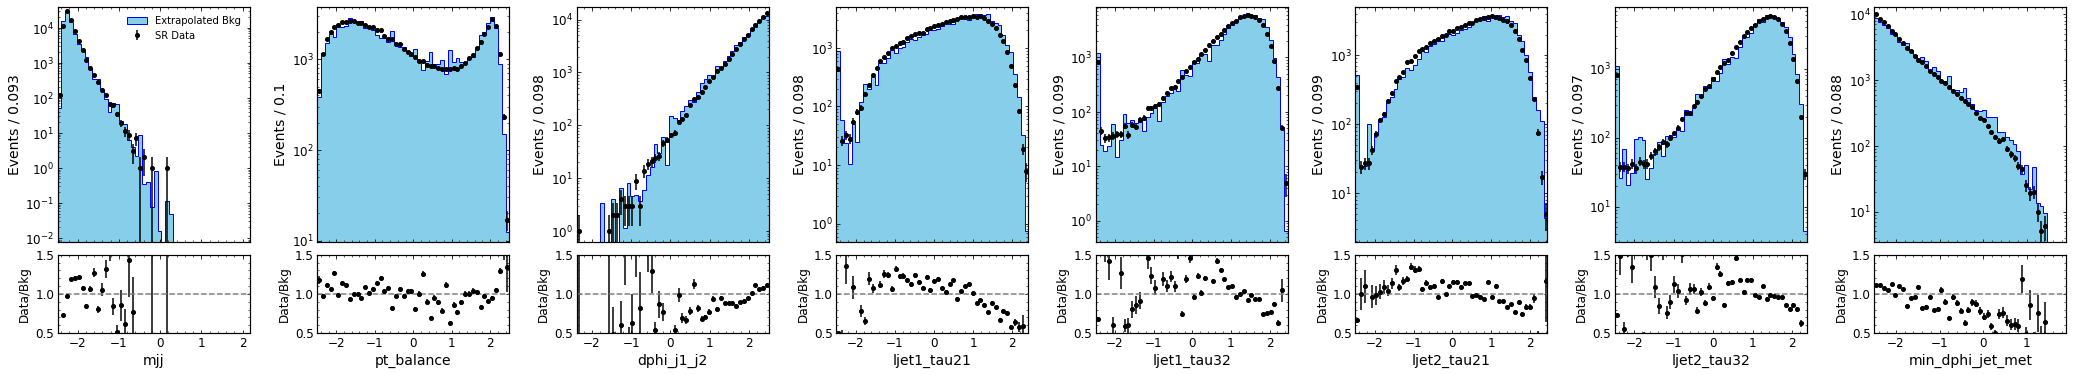

regularizing
regularizing

Working on weight_sr...
      X_train, y_train, w_train: (92054, 8) (92054, 1) (92054, 1)
      X_test, y_test: (23014, 8) (23014, 1)
Classifier run 1 of 20.
Using device: cpu


  0%|          | 0/50 [00:00<?, ?it/s]Exception ignored in: <function _releaseLock at 0x78701e56c820>
Traceback (most recent call last):
  File "/usr/lib/python3.10/logging/__init__.py", line 228, in _releaseLock
    def _releaseLock():
KeyboardInterrupt: 
  0%|          | 0/50 [00:06<?, ?it/s]


RuntimeError: DataLoader worker (pid(s) 40825, 40826, 40827, 40828, 40829, 40830, 40831, 40832, 40833, 40834, 40835, 40836, 40837, 40838, 40839, 40840, 40841, 40842, 40843, 40844, 40845, 40846, 40847, 40848, 40849, 40850, 40851, 40852, 40853, 40854, 40855, 40856, 40857, 40858, 40859, 40860, 40861, 40862, 40863, 40864, 40865, 40866, 40867, 40868, 40869, 40870, 40871, 40872, 40873, 40874, 40875, 40876, 40877, 40878, 40879, 40880, 40881, 40883, 40884) exited unexpectedly

In [8]:
set_1 = mc_events_sr[features].values
set_2 = data_events_sr[features].values
w_1 = np.array(mc_events_sr_weighted["weight_phys"])
w_1 = w_1*(len(set_2)/np.sum(w_1))
print(f"Number of negative weights in w_1: {np.sum(w_1 < 0)}")
plot_publication_features_1row(set_1, set_2, w_1, feature_names=features, save_dir=f"{eval_dir}/publication_plots")
run_eval(set_1, set_2, w_1 = w_1, code=f"weight_sr", save_dir=eval_dir, classifier_params=params, device=device)

CWoLA Evaluation on Generate Samples
CR has 76255 data events, 38813 MC events.
Model path: /home/aegis/Titan1/NRAD/data/Models/context_weight.pt
2
Generating context weights for CR...
Shapes of context variable arrays: (76255, 10) (38813, 2)
Loading model from: /home/aegis/Titan1/NRAD/data/Models/generate.pt
Generating samples
Generating publication plots to diagnose AUC issue...


/tmp/ipykernel_202302/3026741794.py:79: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax_main.set_ylim(0, max_y * 1.3)


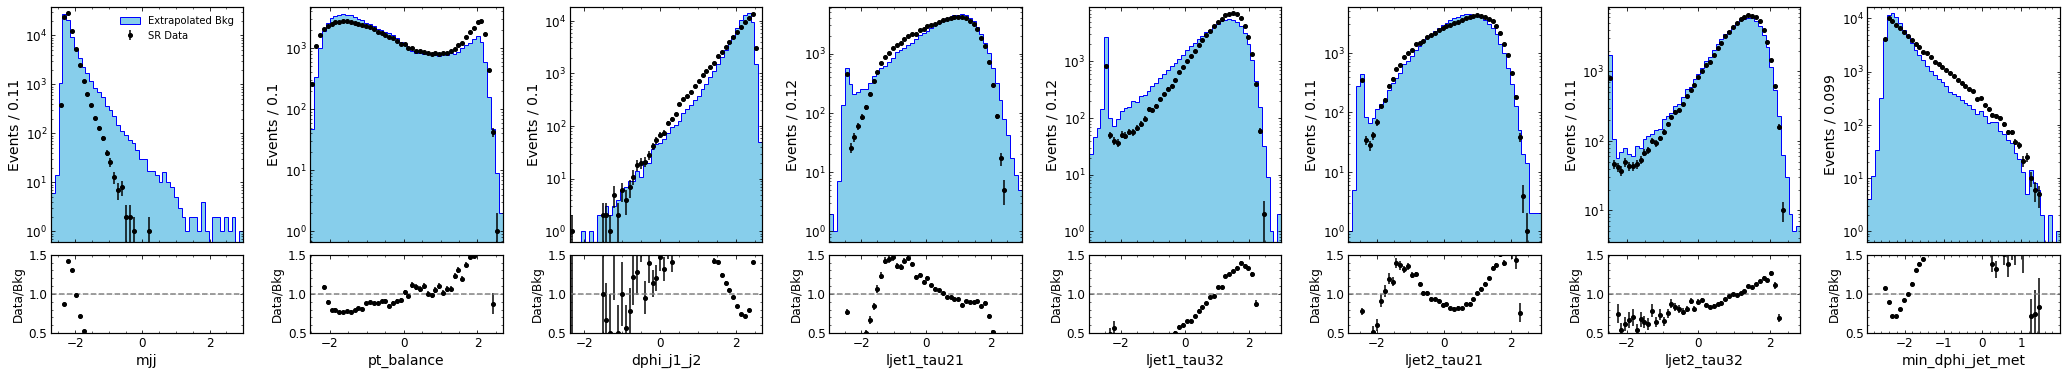

In [ ]:
print("CWoLA Evaluation on Generate Samples")

print("CR has", len(data_events_sr), "data events,", len(mc_events_sr), "MC events.")

data_events_sr_context = data_events_sr[context_var].values
mc_sr_test_context = mc_events_sr[context_var].values

model = "context_weight"
model_path_full = f"{model_path}/{model}.pt"
print("Model path:", model_path_full)

NN_cw = torch.load(model_path_full, weights_only=False, map_location=torch.device('cpu'))
NN_cw.to(device)
print(NN_cw.n_inputs)

print("Generating context weights for CR...")
print("Shapes of context variable arrays:", data_sr_test.shape, mc_sr_test.shape)
w_sr = NN_cw.evaluation(mc_sr_test)
w_sr = (w_sr / (1-w_sr)).flatten()
w_sr = np.nan_to_num(w_sr, copy=False, nan=0.0, posinf=0.0, neginf=0.0)

model_gen = "generate"
model_gen_path_full = f"{model_path}/{model_gen}.pt"
print("Loading model from:", model_gen_path_full)

MAF = torch.load(model_gen_path_full, weights_only=False)
print(MAF)
MAF.to(device)

print("Generating samples")
# weighted_context = mc_sr_test*w_sr[:, np.newaxis]
# pred_bkg_SR = MAF.sample(1, mc_sr_test)
pred_bkg_SR = MAF.sample(1, data_events_sr_context)
# pred_bkg_SR = MAF.sample(1, weighted_context)
lower_bound = -3
upper_bound = 3
valid_events_mask = np.all((pred_bkg_SR >= lower_bound) & (pred_bkg_SR <= upper_bound), axis=1)
pred_bkg_SR = pred_bkg_SR[valid_events_mask]
set_1 = pred_bkg_SR
# plt.plot(set_1)
w_1 = np.ones(set_1.shape[0])*1
set_2 = data_events_sr[features].values
print("Generating publication plots to diagnose AUC issue...")
plot_publication_features_1row(set_1, set_2, w_1, feature_names=features, save_dir=f"{eval_dir}/publication_plots")

run_eval(set_1, set_2, code=f"generate_sr", save_dir=eval_dir, classifier_params=params, device=device)


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_all_comparisons_to_data(
    data_samples,
    unweighted_samples,
    reweight_samples, reweight_weights,
    generate_samples,
    mc_weighted_samples, mc_weights,
    feature_names,
    log_features=None,
    save_dir=None,
    bins=50,
    val_range=(-3.0, 3.0),
    ratio_ylim=(0.5, 1.5)
):
    """
    Plots Data and various MC variants with comprehensive statistical uncertainties.
    Includes beautiful LaTeX formatting for axes labels and titles.
    """
    if log_features is None:
        log_features = []
    if save_dir and not os.path.exists(save_dir):
        os.makedirs(save_dir)
        
    w_unweighted = np.ones(unweighted_samples.shape[0])
    gen_weight_val = len(data_samples) / generate_samples.shape[0]
    w_generate = np.ones(generate_samples.shape[0]) * gen_weight_val

    # Standard High Energy Physics color palette
    colors = {
        'unw': 'tab:blue',
        'rew': 'tab:orange',
        'gen': 'tab:green',
        'mc':  'tab:red',
        'data': 'black'
    }

    # LaTeX mappings for your specific features
    feature_labels = {
        'mjj': r"$m_{jj}$",
        'pt_balance': r"$p_{\text{T}}^{\text{bal}}$",
        'dphi_j1_j2': r"$|\phi_{max} - \phi_{min}|$",
        'ljet1_tau21': r"Jet 1 $\tau_{21}$",
        'ljet1_tau32': r"Jet 1 $\tau_{32}$",
        'ljet2_tau21': r"Jet 2 $\tau_{21}$",
        'ljet2_tau32': r"Jet 2 $\tau_{32}$",
        'min_dphi_jet_met': r"$\min(\Delta\phi(E_{\text{T}}^{\text{miss}}, \text{Jet}))$"
    }

    for i, feature in enumerate(feature_names):
        fig, (ax1, ax2) = plt.subplots(
            nrows=2, ncols=1, figsize=(10, 10), 
            gridspec_kw={'height_ratios': [3, 1]}, sharex=True
        )
        plt.subplots_adjust(hspace=0.05) 
        
        # Get the pretty label, fallback to raw feature name if not found
        display_label = feature_labels.get(feature, feature)
        
        # --- 1. CALCULATE HISTOGRAMS & ERRORS ---
        counts_data, bin_edges = np.histogram(data_samples[:, i], bins=bins, range=val_range)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        err_data = np.sqrt(counts_data) 
        
        counts_unw, _ = np.histogram(unweighted_samples[:, i], bins=bin_edges)
        err_unw = np.sqrt(counts_unw) 
        
        counts_rew, _ = np.histogram(reweight_samples[:, i], bins=bin_edges, weights=reweight_weights)
        var_rew, _ = np.histogram(reweight_samples[:, i], bins=bin_edges, weights=reweight_weights**2)
        err_rew = np.sqrt(var_rew)
        
        counts_gen, _ = np.histogram(generate_samples[:, i], bins=bin_edges, weights=w_generate)
        var_gen, _ = np.histogram(generate_samples[:, i], bins=bin_edges, weights=w_generate**2)
        err_gen = np.sqrt(var_gen)
        
        counts_mc, _ = np.histogram(mc_weighted_samples[:, i], bins=bin_edges, weights=mc_weights)
        var_mc, _ = np.histogram(mc_weighted_samples[:, i], bins=bin_edges, weights=mc_weights**2)
        err_mc = np.sqrt(var_mc)

        # --- 2. MAIN PANEL (TOP) ---
        def plot_mc(ax, counts, errs, color, label):
            ax.hist(bin_centers, bins=bin_edges, weights=counts, histtype='step', 
                    linewidth=2, color=color, label=label, alpha=0.9)
            ax.errorbar(bin_centers, counts, yerr=errs, fmt='none', ecolor=color, alpha=0.5, zorder=3)

        plot_mc(ax1, counts_unw, err_unw, colors['unw'], 'Unweighted MC')
        plot_mc(ax1, counts_rew, err_rew, colors['rew'], 'Reweighted')
        plot_mc(ax1, counts_gen, err_gen, colors['gen'], 'Generated (MAF)')
        plot_mc(ax1, counts_mc, err_mc, colors['mc'], 'MC Weighted')
        
        ax1.errorbar(bin_centers, counts_data, yerr=err_data, fmt='ko', label='Data', zorder=5)
        
        ax1.set_ylabel("Events / Bin", fontsize=12)
        # Use the pretty label in the title
        # ax1.set_title(f"Distribution Comparison for {display_label}", fontsize=14, fontweight='bold')
        ax1.legend(loc='best', frameon=False, fontsize=11)
        ax1.grid(axis='y', linestyle='--', alpha=0.5)
        
        max_y = max(np.max(counts_data), np.max(counts_gen), np.max(counts_mc), np.max(counts_rew))
        if feature in log_features:
            ax1.set_yscale('log')
            ax1.set_ylim(0.1, max_y * 50) 
        else:
            ax1.set_ylim(0, max_y * 1.3)
            
        # --- 3. RATIO PANEL (BOTTOM) ---
        valid_mask = counts_data > 0
        safe_data = np.where(valid_mask, counts_data, 1e-10)
        
        rel_err_data = err_data / safe_data
        rel_err_data[~valid_mask] = 0 
        
        ax2.fill_between(
            bin_edges, 
            np.append(1 - rel_err_data, 1 - rel_err_data[-1]), 
            np.append(1 + rel_err_data, 1 + rel_err_data[-1]), 
            step='post', color='gray', alpha=0.3, label='Data Stat. Unc.', zorder=1
        )
        ax2.axhline(1.0, color='black', linestyle='--', zorder=2)
        
        def plot_ratio(ax, counts, errs, color):
            ratio = counts / safe_data
            ratio_err = errs / safe_data 
            
            ratio_plot = np.where(valid_mask, ratio, np.nan)
            
            ax.step(bin_edges, np.append(ratio_plot, ratio_plot[-1]), where='post', 
                    linewidth=1.5, color=color, alpha=0.8)
            
            ax.errorbar(bin_centers[valid_mask], ratio_plot[valid_mask], 
                        yerr=ratio_err[valid_mask], fmt='none', ecolor=color, alpha=0.5)

        plot_ratio(ax2, counts_unw, err_unw, colors['unw'])
        plot_ratio(ax2, counts_rew, err_rew, colors['rew'])
        plot_ratio(ax2, counts_gen, err_gen, colors['gen'])
        plot_ratio(ax2, counts_mc, err_mc, colors['mc'])
        
        # Use the pretty label on the x-axis
        ax2.set_xlabel(display_label, fontsize=12)
        ax2.set_ylabel("MC / Data", fontsize=12)
        ax2.set_ylim(ratio_ylim) 
        ax2.grid(axis='y', linestyle='--', alpha=0.5)
        
        if save_dir:
            plt.savefig(os.path.join(save_dir, f"{feature}_combined.png"), bbox_inches='tight', dpi=300)
            plt.savefig(os.path.join(save_dir, f"{feature}_combined.pdf"), bbox_inches='tight')
        
        plt.show()
        plt.close()

Loading model from: /home/aegis/Titan1/NRAD/data/Models/reweight.pt
10
Generating samples
[0.4486676  0.28440183 0.42552802 ... 0.11030871 0.5010082  0.5055567 ]
1.9646767835519028
[0.8814868  0.55875766 0.836025   ... 0.21672097 0.9843192  0.9932555 ]
Loading model from: /home/aegis/Titan1/NRAD/data/Models/generate.pt
Generating samples


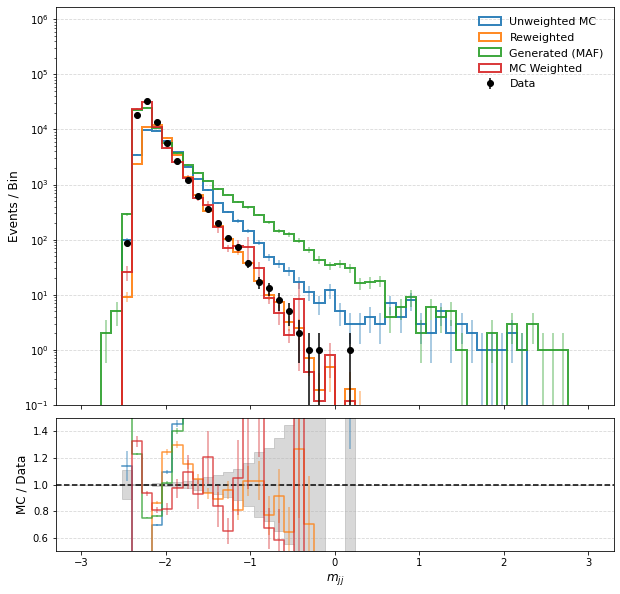

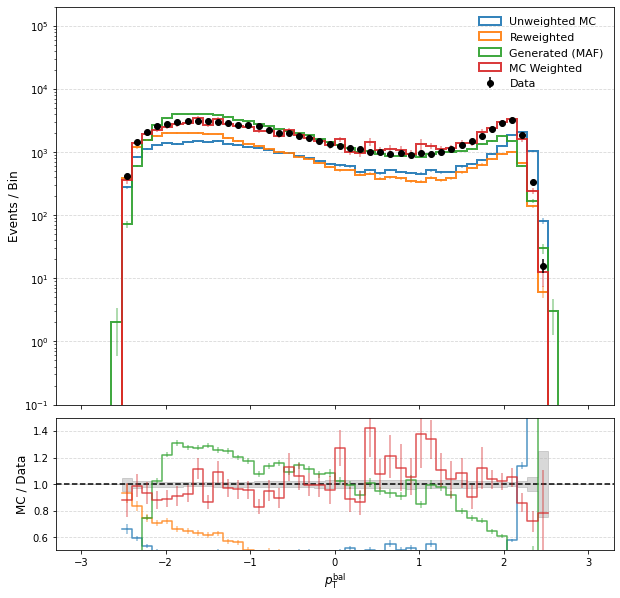

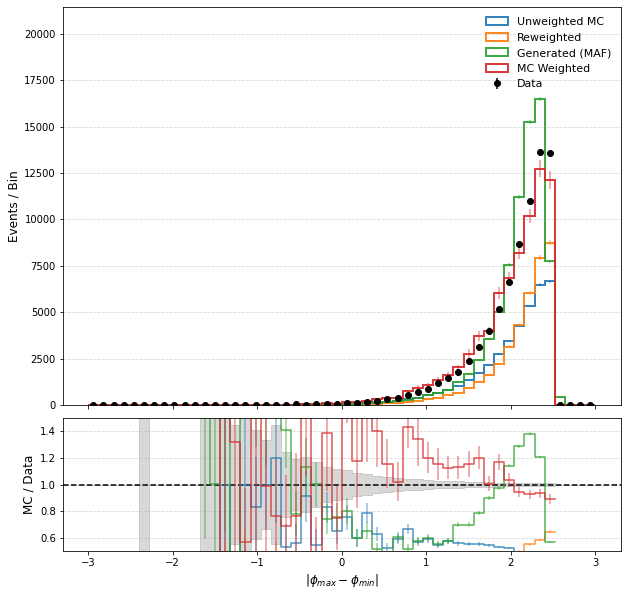

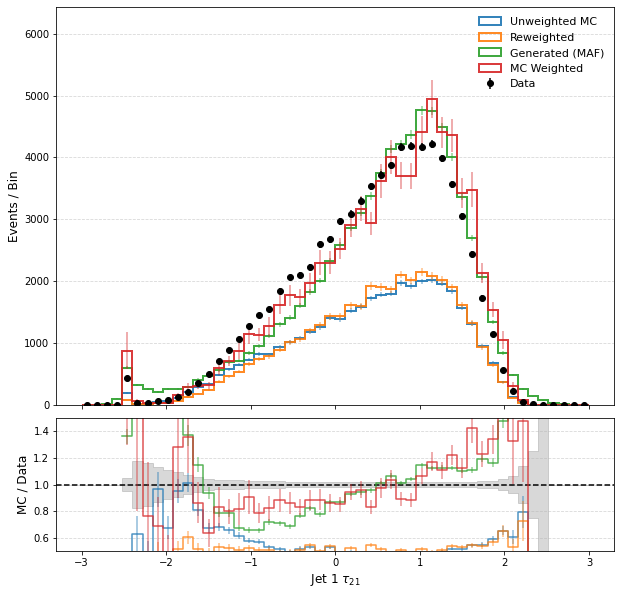

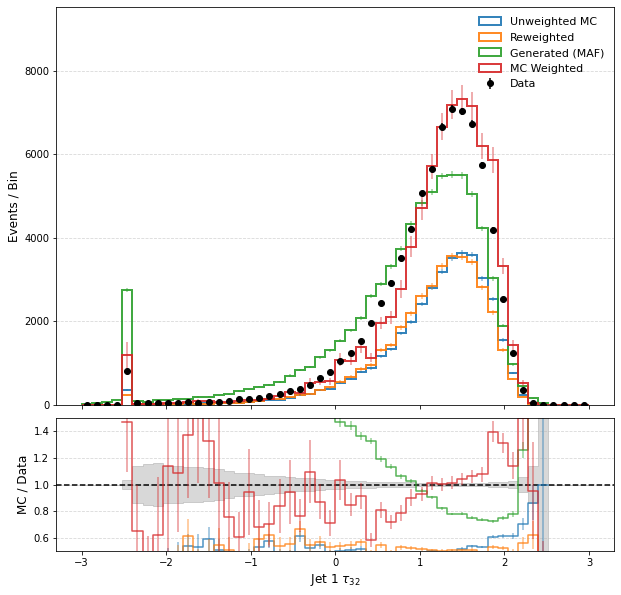

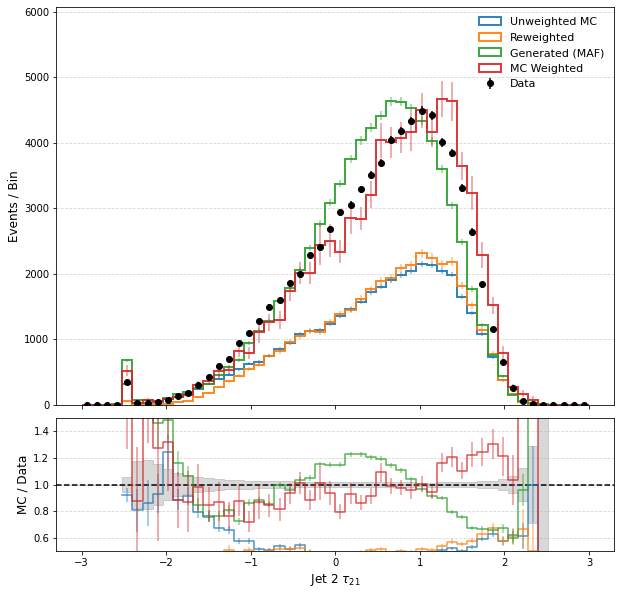

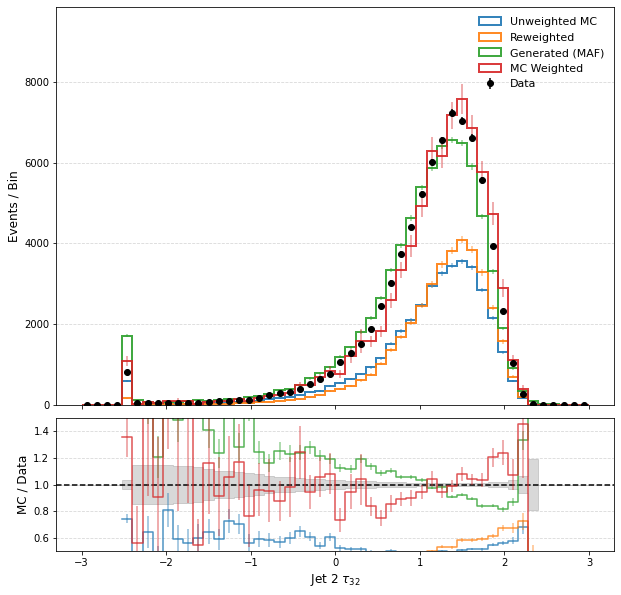

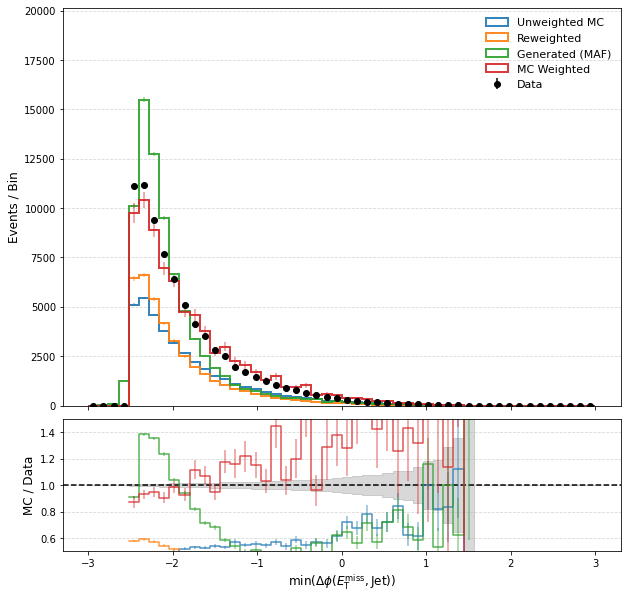

In [7]:
features_list = ['mjj', 'pt_balance', 'dphi_j1_j2', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'min_dphi_jet_met']
features_to_log = ['mjj', 'pt_balance']

unweighted = mc_events_sr[features].values
data_events_sr_context = data_events_sr[context_var].values
set_2 = data_events_sr[features].values
model = "reweight"
model_path_full = f"{model_path}/{model}.pt"
print("Loading model from:", model_path_full)
NN_reweight = torch.load(model_path_full, weights_only=False)
NN_reweight.to(device)

print(NN_reweight.n_inputs)

print("Generating samples")
w_sr = NN_reweight.evaluation(mc_events_sr.values)
w_sr = np.clip(w_sr, 1e-7, 1.0 - 1e-7)
w_sr = (w_sr/(1-w_sr)).flatten()  
print(w_sr)
w_reweight = w_sr*(len(data_events_sr)/len(mc_events_sr))
print((len(data_events_sr)/len(mc_events_sr)))
print(w_reweight)


model_gen = "generate"
model_gen_path_full = f"{model_path}/{model_gen}.pt"
print("Loading model from:", model_gen_path_full)

MAF = torch.load(model_gen_path_full, weights_only=False)
print(MAF)
MAF.to(device)

print("Generating samples")
pred_bkg_SR = MAF.sample(1, data_events_sr_context)
lower_bound = -3
upper_bound = 3
valid_events_mask = np.all((pred_bkg_SR >= lower_bound) & (pred_bkg_SR <= upper_bound), axis=1)
pred_bkg_SR = pred_bkg_SR[valid_events_mask]

mc_weights = np.array(mc_events_sr_weighted["weight_phys"])
mc_weights = mc_weights/np.sum(mc_weights)*len(set_2)
plot_all_comparisons_to_data(data_samples = set_2, 
                             unweighted_samples=unweighted, reweight_samples=unweighted, 
                             reweight_weights=w_reweight, generate_samples=pred_bkg_SR, 
                             mc_weighted_samples=unweighted, mc_weights=mc_weights,
                            feature_names=features_list, log_features=features_to_log,
                            bins=50, val_range=(-3, 3))